# GIFT-Eval

Import packages.

In [ ]:
from itertools import pairwise
from typing import Literal

import lightning as L
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import torch
from gluonts.dataset.field_names import FieldName
from gluonts.dataset.loader import TrainDataLoader, ValidationDataLoader
from gluonts.ev.metrics import (
    MAE,
    MAPE,
    MASE,
    MSE,
    MSIS,
    ND,
    NRMSE,
    RMSE,
    SMAPE,
    MeanWeightedSumQuantileLoss,
)
from gluonts.itertools import Cached
from gluonts.model import evaluate_forecasts
from gluonts.model.forecast_generator import DistributionForecastGenerator
from gluonts.time_feature import get_seasonality
from gluonts.torch.batchify import batchify
from gluonts.torch.distributions import StudentTOutput
from gluonts.torch.model.predictor import PyTorchPredictor
from gluonts.torch.scaler import MeanScaler
from gluonts.torch.util import weighted_average
from gluonts.transform import (
    AddObservedValuesIndicator,
    ExpectedNumInstanceSampler,
    InstanceSplitter,
    TestSplitSampler,
    Transformation,
    ValidationSplitSampler,
)
from gluonts.transform.feature import (
    DummyValueImputation,
    LastValueImputation,
    RollingMeanValueImputation,
)
from torch import nn

from gift_eval.data import Dataset

L.seed_everything(42)

Seed set to 42


42

Define model.

In [ ]:
class FFNNModel(nn.Module):
    def __init__(
        self,
        prediction_length: int,
        context_length: int,
        hidden_dimensions: list[int],
        scaler: Literal["mean", "std", "nop"] = "mean",
    ) -> None:
        super().__init__()
        self.prediction_length = prediction_length
        self.context_length = context_length
        self.hidden_dimensions = hidden_dimensions
        self.scaler = MeanScaler(keepdim=True)
        self.distr_output = StudentTOutput()

        # Create list of layer dimensions
        dimensions = [context_length] + hidden_dimensions[:-1]

        # Create layers
        layers = []
        for d_in, d_out in pairwise(dimensions):
            layers.append(nn.Sequential(nn.Linear(d_in, d_out), nn.ReLU()))
        layers.append(
            nn.Sequential(
                nn.Linear(
                    dimensions[-1],
                    prediction_length * hidden_dimensions[-1],
                ),
                nn.ReLU(),
            )
        )

        # Create model backbone
        self.backbone = nn.Sequential(*layers)

        # Create distribution output head
        self.args_proj = self.distr_output.get_args_proj(hidden_dimensions[-1])

    def forward(
        self,
        past_target: torch.Tensor,
        past_observed_values: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        # Scale the input
        scaled_past_target, loc, scale = self.scaler(
            past_target,
            past_observed_values,
        )

        # Pass through layers
        hidden_state = self.backbone(scaled_past_target)

        # Reshape the hidden state for the distribution head
        reshaped_hidden_state = hidden_state.reshape(
            -1,
            self.prediction_length,
            self.hidden_dimensions[-1],
        )

        # Project the hidden state to the distribution parameters
        distr_args = self.args_proj(reshaped_hidden_state)
        return distr_args, loc, scale

    def get_predictor(
        self,
        input_transform: Transformation,
        batch_size: int = 32,
    ) -> PyTorchPredictor:
        return PyTorchPredictor(
            prediction_length=self.prediction_length,
            input_names=["past_target", "past_observed_values"],
            prediction_net=self,
            batch_size=batch_size,
            input_transform=input_transform,
            forecast_generator=DistributionForecastGenerator(self.distr_output),
        )

Define Lightning module.

In [37]:
class FFNNLightningModule(L.LightningModule):
    def __init__(
        self,
        prediction_length: int,
        context_length: int,
        hidden_dimensions: list[int],
        scaler: Literal["mean", "std", "nop"] = "mean",
        lr: float = 1e-3,
    ):
        super().__init__()
        self.model = FFNNModel(
            prediction_length,
            context_length,
            hidden_dimensions,
            scaler,
        )
        self.lr = lr

    def training_step(
        self,
        batch: dict[str, torch.Tensor],
        batch_idx: int,
    ) -> torch.Tensor:
        # Forward pass and compute loss
        loss = self.compute_loss(
            past_target=batch["past_target"],
            past_observed_values=batch["past_observed_values"],
            future_target=batch["future_target"],
            future_observed_values=batch["future_observed_values"],
        )
        return loss.mean()

    def validation_step(
        self,
        batch: dict[str, torch.Tensor],
        batch_idx: int,
    ) -> torch.Tensor:
        # Forward pass and compute loss
        loss = self.compute_loss(
            past_target=batch["past_target"],
            past_observed_values=batch["past_observed_values"],
            future_target=batch["future_target"],
            future_observed_values=batch["future_observed_values"],
        )
        loss = loss.mean()

        # Log the val loss, averaged over the epoch rather than per batch
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)

        return loss

    def compute_loss(
        self,
        past_target: torch.Tensor,
        past_observed_values: torch.Tensor,
        future_target: torch.Tensor,
        future_observed_values: torch.Tensor,
    ) -> torch.Tensor:
        # Forward pass
        distr_args, loc, scale = self.model(
            past_target=past_target,
            past_observed_values=past_observed_values,
        )

        # Compute loss
        loss = self.model.distr_output.loss(
            target=future_target,
            distr_args=distr_args,
            loc=loc,
            scale=scale,
        )

        # Only compute loss on observed values
        return weighted_average(loss, weights=future_observed_values, dim=-1)

    def configure_optimizers(self) -> torch.optim.Optimizer:
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        return optimizer

Load dataset.

In [38]:
name = "m4_hourly"
term = "short"
dataset = Dataset(name)

Create transformations.

In [39]:
context_length = 4 * dataset.prediction_length
prediction_length = dataset.prediction_length

imputation = "dummy_value"
# imputation = "last_value"
# imputation = "rolling_mean"

imputation_method = {
    "dummy_value": DummyValueImputation(),
    "last_value": LastValueImputation(),
    "rolling_mean": RollingMeanValueImputation(
        window_size=get_seasonality(dataset.freq)
    ),
}[imputation]

add_observed_values_indicator = AddObservedValuesIndicator(
    target_field=FieldName.TARGET,
    output_field=FieldName.OBSERVED_VALUES,
    imputation_method=imputation_method,
)

training_sampler = ExpectedNumInstanceSampler(
    num_instances=1,
    min_future=prediction_length,
)

validation_sampler = ValidationSplitSampler(
    min_future=prediction_length,
)

test_sampler = TestSplitSampler()

splitter_kwargs = {
    "target_field": FieldName.TARGET,
    "is_pad_field": FieldName.IS_PAD,
    "start_field": FieldName.START,
    "forecast_start_field": FieldName.FORECAST_START,
    "past_length": context_length,
    "future_length": prediction_length,
    "time_series_fields": [FieldName.OBSERVED_VALUES],
}

training_splitter = InstanceSplitter(
    instance_sampler=training_sampler,
    **splitter_kwargs,
)

validation_splitter = InstanceSplitter(
    instance_sampler=validation_sampler,
    **splitter_kwargs,
)

test_splitter = InstanceSplitter(
    instance_sampler=test_sampler,
    **splitter_kwargs,
)

training_transform = add_observed_values_indicator + training_splitter
validation_transform = add_observed_values_indicator + validation_splitter
test_transform = add_observed_values_indicator + test_splitter

C:\Users\Mike\vscode\gift-eval\src\gift_eval\data.py:151: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = norm_freq_str(to_offset(self.freq).name)
c:\Users\Mike\anaconda3\envs\gifteval\Lib\site-packages\gluonts\time_feature\seasonality.py:47: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset = pd.tseries.frequencies.to_offset(freq)


Create dataloaders.

In [40]:
batch_size = 32
num_batches_per_epoch = 50

train_loader = TrainDataLoader(
    dataset=Cached(dataset.training_dataset),
    transform=training_transform,
    stack_fn=batchify,
    batch_size=batch_size,
    num_batches_per_epoch=num_batches_per_epoch,
)

validation_loader = ValidationDataLoader(
    dataset=Cached(dataset.validation_dataset),
    transform=validation_transform,
    stack_fn=batchify,
    batch_size=batch_size,
)

Train the model.

In [ ]:
max_epochs = 10

estimator = FFNNLightningModule(
    prediction_length=prediction_length,
    context_length=context_length,
    hidden_dimensions=[96, 48],
)

trainer = L.Trainer(max_epochs=max_epochs, logger=True)
trainer.fit(estimator, train_loader, validation_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name  | Type      | Params | Mode  | FLOPs
----------------------------------------------------
0 | model | FFNNModel | 242 K  | train | 0    
----------------------------------------------------
242 K     Trainable params
0         Non-trainable params
242 K     Total params
0.969     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Evaluate the model.

In [42]:
predictor = estimator.model.get_predictor(
    test_transform,
    batch_size=batch_size,
)

forecasts = predictor.predict(dataset.test_data.input)

metrics = [
    MSE(forecast_type="mean"),
    MSE(forecast_type=0.5),
    MAE(),
    MASE(),
    MAPE(),
    SMAPE(),
    MSIS(),
    RMSE(),
    NRMSE(),
    ND(),
    MeanWeightedSumQuantileLoss(
        quantile_levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    ),
]

results_df = evaluate_forecasts(
    forecasts=forecasts,
    test_data=dataset.test_data,
    metrics=metrics,
    batch_size=batch_size,
    axis=None,
    mask_invalid_label=True,
    allow_nan_forecast=False,
    seasonality=get_seasonality(dataset.freq),
)

results_df.head()

414it [00:08, 47.43it/s]


,MSE[mean],MSE[0.5],MAE[0.5],MASE[0.5],MAPE[0.5],sMAPE[0.5],MSIS,RMSE[mean],NRMSE[mean],ND[0.5],mean_weighted_sum_quantile_loss
None,4.929321e+06,4.929321e+06,418.012166,3.775445,0.204688,0.165953,39.198153,2220.207379,0.303107,0.057068,0.045625


Plot the forecast and ground-truth.

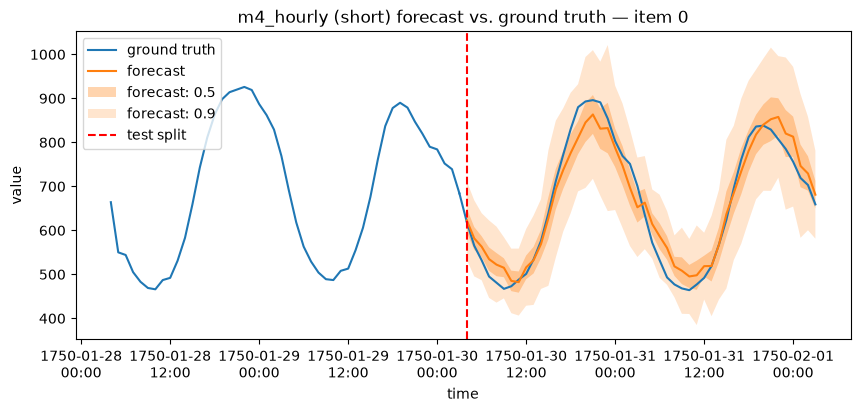

In [43]:
input_entry, label_entry = next(iter(dataset.test_data))
forecast = next(iter(predictor.predict([input_entry])))

# The model's context window ending right where the test split begins;
# its last `prediction_length` points are the validation split.
recent_history = input_entry["target"][-context_length:]
train_target = recent_history[:-prediction_length]
validation_target = recent_history[-prediction_length:]

validation_start = forecast.start_date - prediction_length
validation_index = pd.period_range(
    start=validation_start,
    periods=len(validation_target),
    freq=forecast.start_date.freq,
)
train_index = pd.period_range(
    start=validation_start - len(train_target),
    periods=len(train_target),
    freq=forecast.start_date.freq,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    validation_index.to_timestamp(),
    validation_target,
    color="tab:blue",
)
# Connect the last validation point to the first ground-truth point so the
# line doesn't visibly stop one sample short of the test split.
ax.plot(
    [validation_index[-1].to_timestamp(), forecast.index[0].to_timestamp()],
    [validation_target[-1], label_entry["target"][0]],
    color="tab:blue",
)
ax.plot(
    forecast.index.to_timestamp(),
    label_entry["target"],
    label="ground truth",
    color="tab:blue",
)
forecast.plot(
    intervals=(0.5, 0.9),
    name="forecast",
    show_label=True,
    color="tab:orange",
    ax=ax,
)
ax.axvline(
    forecast.start_date.to_timestamp(),
    color="red",
    linestyle="--",
    label="test split",
)

# Show the year explicitly on the tick labels instead of relying on the
# (easy to miss) offset text in the corner of the axes.
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

ax.set_title(f"{name} ({term}) forecast vs. ground truth — item {forecast.item_id}")
ax.set_xlabel("time")
ax.set_ylabel("value")
ax.legend()
plt.show()